# Lecture 09a. Clustering: `KMeans` implementation from `scikit-learn`

**Preliminary Definitions**

* Algorithm: a finite, step-by-step procedure that transforms inputs into outputs to solve a problem.
* Cluster: a group of observations that are more similar to each other than to observations in other groups.
* Unsupervised learning: learning patterns from data **without** labelled targets (no `y`); the algorithm discovers structure on its own.

## What is Kmeans

Introduction to `Kmeans` by [my favourite tutor.](https://www.youtube.com/watch?v=lQ39ZRFfYbI)

`KMeans` is an "unsupervised learning" algorithm → We don't know the labels. We assign intuitive labels according to the data.   
We don't have a "y" target variable that we want to predict.  

The goal is to create K groups (clusters) of homogeneous observations.   
The number K of groups is unknown. The labels of the groups are unknown.  
A more accurate description could be "unlabelled learning".

Using what the data suggest, we chose the number of groups, and then we think of appropriate and intuitive labels to describe each cluster (group).     

Centroids: the centre of the cluster. Maybe an actual observation in the data or not.  

Measuring success:   
a) minimise the total distance of all observations from the centroid. This metric is called "inertia" or "**Within Cluster Sum of Squares (WCSS)**",    
b) maximise cluster "cohesion", how  similar are the observations in a cluster compared to other clusters (Silhouette Score).   
c) for all available metrics on scikit-learn please read the relevant section.  

Important note:   
The number of groups (clusters) in social sciences is in many cases a matter of policy, a strategic decision based on possible insights of the data.   
It depends on how much we want to "zoom out" or "zoom in" the data - argythana(tm).      
The number of clusters in positive science is in most cases predetermined. E.g. Fraud, Measurement error.

We may examine and report about the data for different numbers of clusters depending on our needs.   
In most cases, we start from 2 clusters and increase K up to a reasonable point.    
Often, there is no "correct" number of clusters.  

Actually, "unsupervised" learning ["is somewhat supervised"](https://www.youtube.com/watch?v=JbP9EPPvVXg) to an extent.   
I would add that clustering is similar to classification of observations to "unknown classes".
These new "classes" can in turn be labelled according to users needs.  

Clustering can be thought of as trying to "classify" to unknown categories (classes), when we don't know the existing classes of the observations.  

## When KMeans is a good fit (shape and data size) and what to watch out for

- KMeans works best when the clusters are roughly **spherical (round "blobs") of similar size and density**, on **numeric features scaled to comparable ranges** (e.g. standardised). It struggles when clusters are elongated, curved, ring-shaped, or have very different sizes — in those cases consider DBSCAN, spectral clustering, or Gaussian Mixture Models. More reading on this in the dedicated notebook.

- KMeans is also **sensitive to outliers**, because a single distant point can pull a centroid noticeably. 
- Categorical features must be encoded numerically (as we do later with `Genre` → `Gender`).

For more, examine the [comparison of various clustering algorithms](https://scikit-learn.org/stable/auto_examples/cluster/plot_cluster_comparison.html#sphx-glr-auto-examples-cluster-plot-cluster-comparison-py**)

## Is KMeans compute-intensive?
 
For typical datasets, **no** — it is one of the fastest clustering algorithms. Each iteration costs roughly `O(n × k × d)` (number of points × number of clusters × number of features), and it usually converges in a small number of iterations. A laptop can comfortably cluster hundreds of thousands of points with a handful of clusters in seconds. For very large data (millions of rows), scikit-learn provides `MiniBatchKMeans`, which trades a tiny bit of accuracy for a big speed-up by fitting on small random batches.

In [167]:
# Uncomment the line below to read the documentation about KMeans.
# KMeans?

## Lecture resources

- [Tutorial on Kmeans from kaggle](https://www.kaggle.com/satishgunjal/tutorial-k-means-clustering), improvements, additions by Thanasis Argyriou
- [The mall customers dataset, source: Kaggle](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)
- [Dataset Info](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)
- [Kmeans implementation from scikit learn](https://scikit-learn.org/stable/modules/clustering.html#k-means)
- [What is scikit learn](https://scikit-learn.org/stable/getting_started.html)

## 1. Import the necessary modules.   

Make sure you activate the virtual environment and install the necessary packages first.  

The new package that we install in this lecture is `scikit-learn`.

In [168]:
# python -m pip install -U scikit-learn  # -U means --upgrade if already installed

In [169]:
# data management libraries
import pandas as pd

# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# interactive visualizarion libaries
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# scikit learn clustering library
from sklearn.cluster import KMeans
# import the silhouette metric
from sklearn.metrics import silhouette_score

## 2. Load the data using the correct path 

In [170]:
# If your notebook is in the same folder as the data file just use the files name.
df = pd.read_csv("mall_customers.csv")

In [171]:
# If you data is inside a folder called data, two folders above your current working folder:
# You get extra points for that in the final assignment

#df = pd.read_csv("../../data/mall_customers.csv")

# Or use an absolute path, that is too ugly, and will NOT work for you because you a different user. You are not tharg.
#df = pd.read_csv("C:\\Users\\tharg\\uoa_py_course\\data\\mall_customers.csv")

### Understand the data features.   
See which are the variables, what is their type, what are the values that the variables take.  
At this step, you should think about possible relations that you ought to examine.   
Which do you think might be more important?

In [172]:
# show first lines of dataset
df.head(3)

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [173]:
# show column names of dataset.
# 5 columns with suboptimal names.
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual_Income_(k$)', 'Spending_Score'], dtype='object')

In [174]:
# show data types of dataset.
# four numeric, one categorical variable type.
df.dtypes

CustomerID             int64
Genre                 object
Age                    int64
Annual_Income_(k$)     int64
Spending_Score         int64
dtype: object

In [175]:
# simple commnand to show column names and data types.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          200 non-null    int64 
 1   Genre               200 non-null    object
 2   Age                 200 non-null    int64 
 3   Annual_Income_(k$)  200 non-null    int64 
 4   Spending_Score      200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### Short summary notes about the variables.

CustomerID is not useful, unless you know "who is who".  

Spending score is what makes a huge difference. How could we group the customers, according to their spending score, gender, income, age?   

The second most important variable, in this case, should be annual income.  

Gender might, or might might not make a difference.  

Age is a tricky variable. Depending in the issue in question, it might be in linear correlation with the other variables, or it might grow and then gradually fall in importance. e.g. The possibility of deseases and age should be correlated and should grow as age grows.   

On the other hand, income could grow as age grows but then, after retirement, as age grows income might fall. The same line of thought might apply to age and spending score.

## 3. Descriptive statistics and Exploratory Data Analysis (EDA)

### 3.1. Descriptive Statistics

In [176]:
# get rid of customer ID column, useless in this case.
df = df.drop("CustomerID", axis=1)  # axis=1 means drop a column, axis=0 would mean drop a row.

In [177]:
# very basic Descriptive Statistics
df.describe()  # show only numeric variables

,Age,Annual_Income_(k$),Spending_Score
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [178]:
# df.describe(include='all')

In [179]:
# Descriptive stats for categorical variables.
df.describe(include=object)

# alternative way to desribe one single column.
#df.Genre.describe()

,Genre
count,200
unique,2
top,Female
freq,112


In [180]:
# count number of observations in Genre column.
df.Genre.value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

In [181]:
# number of observations in Genre column, in percentage.
df["Genre"].value_counts(normalize=True)

Genre
Female    0.56
Male      0.44
Name: proportion, dtype: float64

### Short summary of descriptive statistics about the data.

200 observations.  
Younger is 18, older is 70, mean age is 38.85 (whatever that age means).     
Highest income is 137k, lowest is 15k, mean income is 60.5k.  
The gender distribution is slightly skewed towards "Female", with 112 observations "Female" (56%) and 88 "Male".

### 3.2. Exploratory Data Analysis   
Plot the variables one by one, then in pairs, or by three and see what story the graphs may tell.

In [182]:
# sns.histplot?

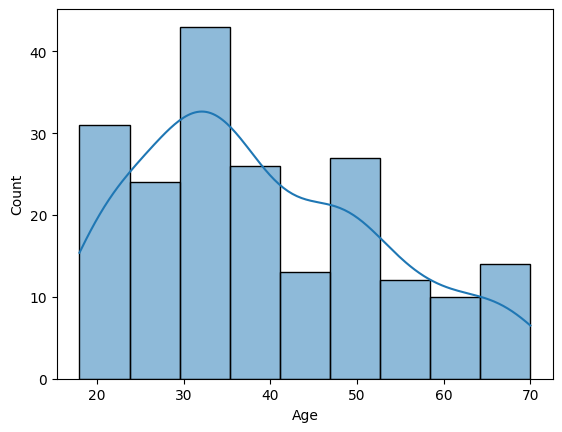

In [183]:
# Basic univariate plot
sns.histplot(x=df["Age"], kde=True);

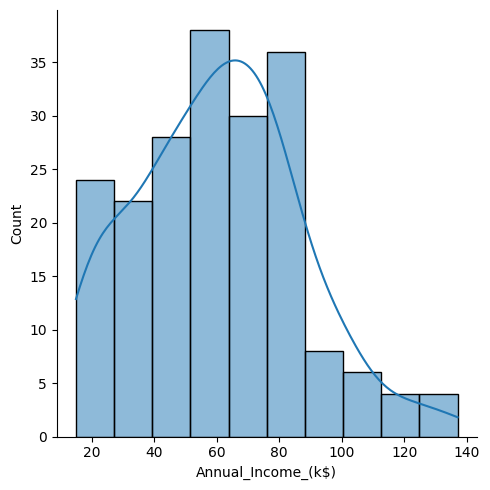

In [184]:
# same as above, different syntax
sns.displot(x=df["Annual_Income_(k$)"], kde=True);

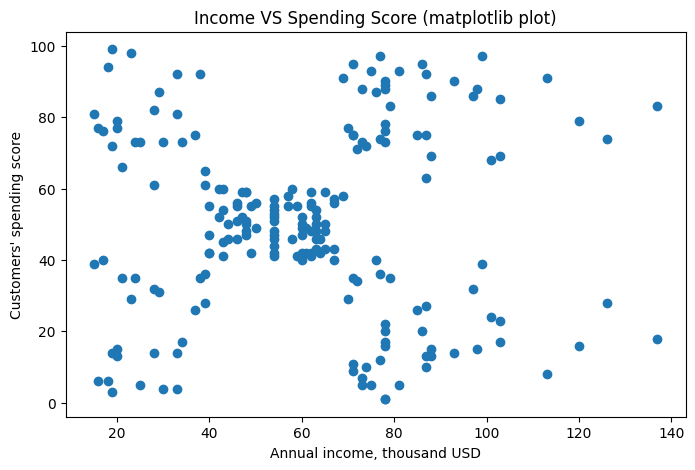

In [185]:
# simple, 'quick and dirty' plot for varibles and their relationships.
# each visualization library has slightly different "syntax" and "names".
# here we use matplotlib library and the scatter() function.
plt.figure(figsize=(8,5))
plt.scatter(
    x=df["Annual_Income_(k$)"],
    y=df["Spending_Score"]
        )

# add title and axis labels to the plot.
plt.title("Income VS Spending Score (matplotlib plot)")
plt.ylabel("Customers' spending score")
plt.xlabel("Annual income, thousand USD");

We can observe 5 or 7 clusters from this plot.

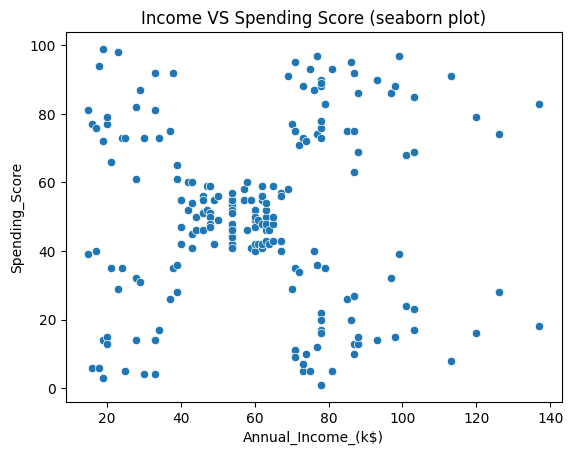

In [186]:
# Each visualization library has slpython -m pip install -U scikit-learnightly different "syntax" and "names".
# For the plot below we use `seaborn` library and the `scatterplot()` function.
# Notice how we set the title of the plot using the `set()` function, which is a bit different from how we set the title in matplotlib or plotly.
sns.scatterplot(
    data=df,
    x="Annual_Income_(k$)",
    y="Spending_Score",
    ).set(title="Income VS Spending Score (seaborn plot)");

In [187]:
# Each visualization library has slightly different "syntax" and "names".
# For the plot below we use `plotly express` library and the `scatter()` function.
# Notice how we set the title of the plot using the `title` argument of the `scatter()` function.
# This is a bit different from how we set the title in matplotlib or seaborn.
px.scatter(
    data_frame=df,
    x="Annual_Income_(k$)",
    y="Spending_Score",
    height=400, width=400,
    title="Income versus spending score, plotly plot"
    )

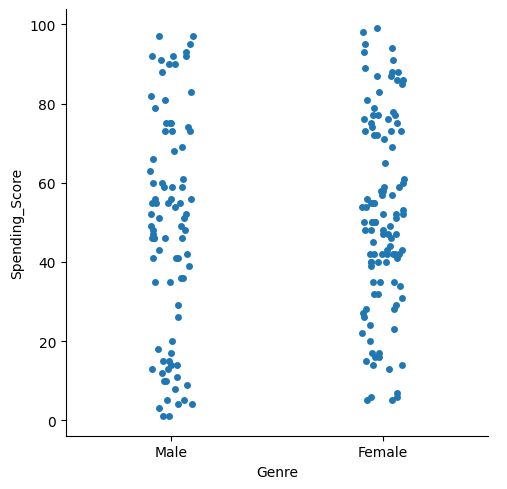

In [188]:
# plot categorical variable with numerical variable.
sns.catplot(
    data=df,
    x="Genre",
    y="Spending_Score",
    # height=400, width=400,
    );

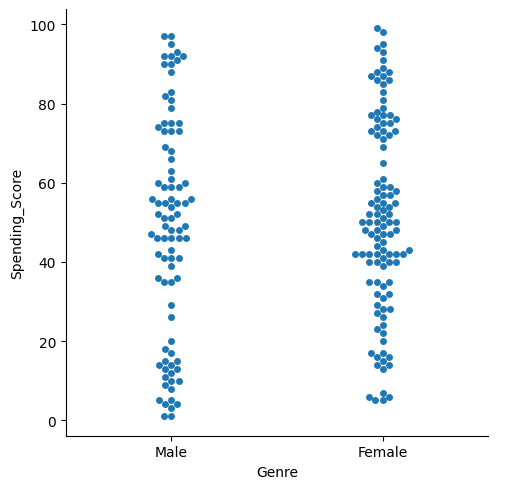

In [189]:
# same as above, different syntax.
sns.catplot(
    data=df,
    x="Genre", 
    y="Spending_Score",  
    kind="swarm"
    );

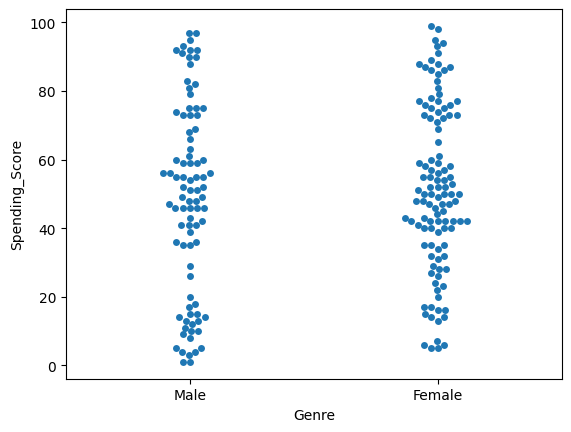

In [190]:
# same as above, different syntax
# different default values for figure size and spines.
sns.swarmplot(
    data=df,
    x="Genre",
    y="Spending_Score"
    );


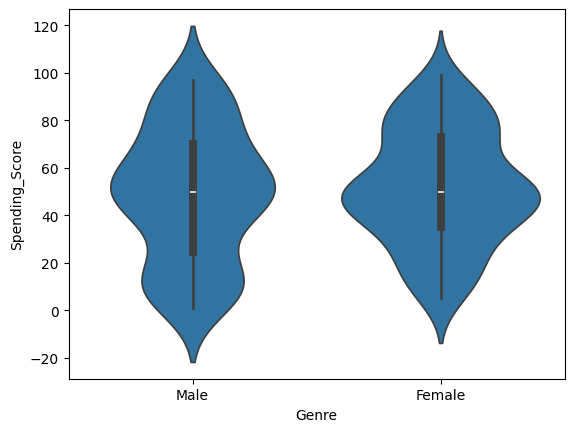

In [191]:
sns.violinplot(
    data=df,
    x="Genre", 
    y="Spending_Score"
    );
# not very informative plot for these variables.
# But, we see more observations of type female towards the median.

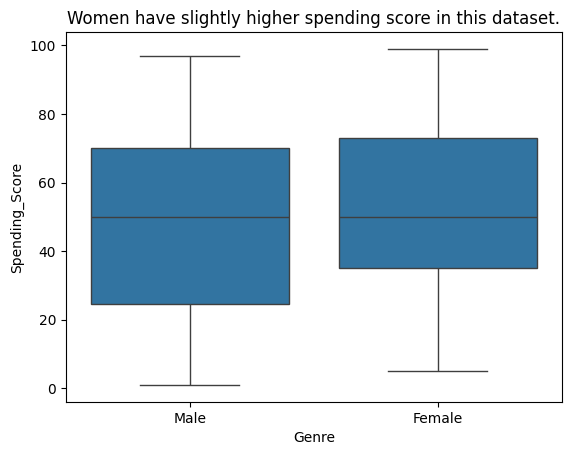

In [192]:
sns.boxplot(
    data=df,
    x="Genre",
    y="Spending_Score"
    ).set(title="Women have slightly higher spending score in this dataset.");

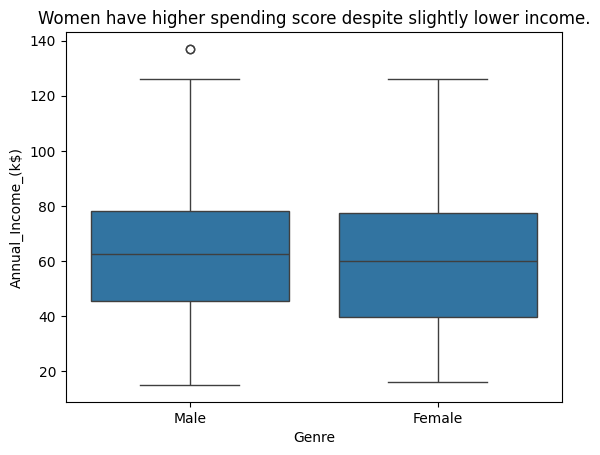

In [193]:
sns.boxplot(
    data=df,
    x="Genre",
    y="Annual_Income_(k$)"
    ).set(
    title="Women have higher spending score despite slightly lower income.");

In [194]:
# not a big difference it seems, but plots are not good enough for small differences.
px.scatter(
    data_frame=df,
    x="Annual_Income_(k$)",
    y="Spending_Score",
    facet_col="Genre",
    color="Genre",
    height=400, width=800
    )

#### Simple descriptive stats on the mean and median of the two genders shows preliminary evidence of a very small difference.   

Plots are not good enough for small differences.

In [195]:
# show mean income by gender. Female average income is lower.
df.groupby('Genre', as_index=False)['Annual_Income_(k$)'].mean()

,Genre,Annual_Income_(k$)
0,Female,59.250000
1,Male,62.227273


In [196]:
# show mean income and spending score by gender
df.groupby('Genre')[['Annual_Income_(k$)', 'Spending_Score']].mean()

,Annual_Income_(k$),Spending_Score
Genre,,
Female,59.250000,51.526786
Male,62.227273,48.511364


In [197]:
# show median of income and spending score by gender
df.groupby('Genre')[['Annual_Income_(k$)', 'Spending_Score']].median()

,Annual_Income_(k$),Spending_Score
Genre,,
Female,60.0,50.0
Male,62.5,50.0


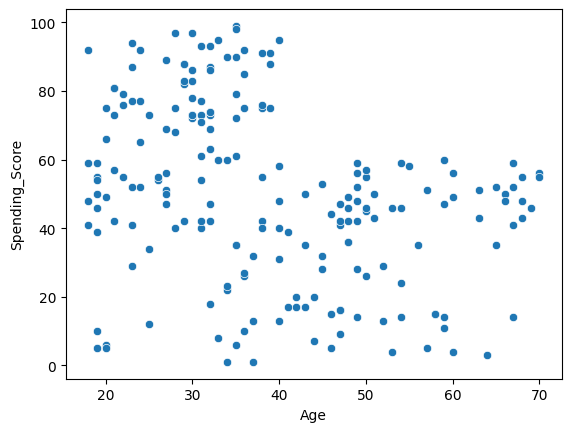

In [198]:
# plot Age and Score.
sns.scatterplot(
    data=df,
    x="Age",
    y="Spending_Score"
    );
# No one above 40 years old has spending score > 60

In [199]:
# plot Age and Score and add some color to your gender life.
px.scatter(
    data_frame=df,
    x="Age",
    y="Spending_Score",
    color="Genre",
    height=500, width=700
    )

No one above 40 years old has spending score > 60.  
Very few customers below 30 years old have low spending score < 40.  

**The highest spending scores appear to be also a matter of age and not only a matter of income.**

This is the first tutorial that shows this conclusion (after reading dozens of tutorials on kaggle, here is some original data insight).

In [200]:
# each visualization library has slightly different "syntax" and "names".
# For the plot below we use plotly express library and the scatter() function.
# See how to use tight layout margins.
px.scatter(
    data_frame=df, 
    x="Age", 
    y="Annual_Income_(k$)",
    height=400, width=600,
    title="Age versus Income",
    ).update_layout(margin=dict(t=35, l=15, r=15, b=15))

In [201]:
px.scatter(df,
        x="Age",
        y="Annual_Income_(k$)",
        color="Genre",
        height=400, width=600,
        title="Age versus Income, by Gender",
        ).update_layout(margin=dict(t=35, l=15, r=15, b=15))


The plots above confirm that there are no customers aged 20 to 27 with income above 90.    
Still, there are many in this age reange with the highest spending scores.

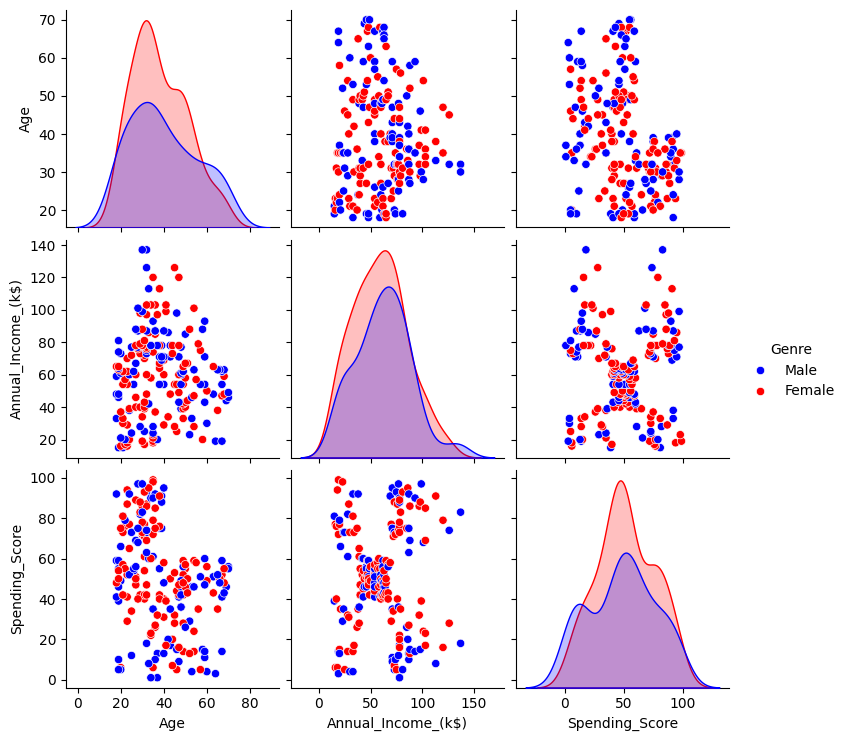

In [202]:
# a pairplot is a quick way to visualize relationships between all pairs of variables in a dataset.
sns.pairplot(
    data=df,
    hue='Genre',
    palette=['Blue', 'Red']
    );

The plot above shows a bit higher spending score for women.  
The higher distribution peaks for female are there because there are more "female" observations.    
The distribution of spending score for women is a bit shifted to the right (bottom right plot).    
But, that difference is again very small and might be true only in this small dataset (sample bias).

In [203]:
# Boxplots are a good way to compare distributions of a numerical variable across different categories of a categorical variable. 
# They show the median, quartiles, and potential outliers in the data. In this case, we can use boxplots to compare the spending scores
# We use make_subplots which is another function from plotly library that allows us to create multiple subplots in one figure.
# We specify that we want 1 row and 2 columns of subplots, and we set horizontal_spacing to False to remove the space between the two subplots.

fig = make_subplots(rows=1, cols=2, horizontal_spacing=False, shared_yaxes=True)

fig.append_trace(go.Box(y=df[df['Genre']=='Male']['Spending_Score'],
                        name='Male', boxpoints='all'), row=1, col=1)

fig.append_trace(go.Box(y=df[df['Genre']=='Female']['Spending_Score'],
                        name='Female', boxpoints='all'), row=1, col=2)

fig.update_layout(title='Spending score for Men vs Women:',
                 plot_bgcolor='#fff',
                 yaxis=dict(showticklabels=False),
                 height=400, width=600,
                 ).update_layout(margin=dict(t=60, l=5, r=0, b=15))

fig.add_annotation(x=0.5, y=1.1, text='<b>Women have slightly higher spending score</b>',
                   xref='paper', yref='paper', showarrow=False)
fig.show()

### Plot 4 dimensions (4 features) on the 3D space.   
Try different views, angles, perspectives, zooms to see how the data points look like.   

There are at least five clusters and the middle one appears more densely populated.

In [204]:
three_dim_fig = px.scatter_3d(
    df,
    x="Annual_Income_(k$)",
    y="Spending_Score",
    z="Age",
    color="Genre",
    height=600, width=900,
    color_discrete_map={"Male": "blue", "Female":"red"},
).update_layout(margin=dict(t=40, l=40, r=40, b=40))#.update_scenes(xaxis_autorange="reversed")

three_dim_fig.update_traces(marker_size = 4)

three_dim_fig.show()

# save to file, use everywhere, since it can be opened in a browser
# three_dim_fig.write_html("three_dim_customers.html")

#### This plot shows that ALL the customers with low annual income and high spending score belong to a relatively young age, < 35 years old

## 4. Apply KMeans: simple example with two features and five clusters

We start with two variables (`Annual_Income_(k$)` and `Spending_Score`) and ask for five clusters.

### A quick note on `.fit()`, `.predict()` and `.fit_predict()`

In `scikit-learn`, almost every model — supervised or unsupervised — follows the **same workflow**:   

First **create** a model, then **train** it on data, and finally you **use it** to make predictions on data. The three methods below are the building blocks of that workflow:

- **`model.fit(X)`** &nbsp;→&nbsp; **train (learn from the data).**
  This is where the actual algorithm runs. For `KMeans`, calling `model.fit(X)` runs Lloyd's algorithm on the matrix `X`: it places the centroids, assigns each point to the nearest centroid, moves the centroids to the mean of their assigned points, and repeats until the centroids stop moving. After `fit`, the trained information is **stored on the model object itself** in attributes whose names end with an underscore, e.g. `model.cluster_centers_` (the final centroid coordinates) and `model.labels_` (the cluster each training point ended up in). `fit` does not return the predictions — it returns the fitted model. Think of it as: *"learn the structure of `X` and remember it."*

- **`model.predict(X_new)`** &nbsp;→&nbsp; **use the trained model on (possibly new) data.**
  Once the model has been fitted, `predict` takes a matrix of observations and returns a 1D array of cluster labels (integers `0, 1, 2, ...`) — one label per row. The model itself is **not changed** by calling `predict`; the centroids learned during `fit` are reused to assign each new point to its nearest centroid. You can call `predict` on the same `X` you trained on (to recover the training labels) or on completely new customers you have never seen before. Think of it as: *"given what you already learned, where does each of these points belong?"*

- **`model.fit_predict(X)`** &nbsp;→&nbsp; **shortcut: do both in one call.**
  This is exactly equivalent to calling `model.fit(X)` and then `model.predict(X)` on the **same** data — it trains the model on `X` and immediately returns the cluster labels for those same rows. It is the convenient one-liner you will see most often in clustering examples, because in unsupervised learning you usually want the labels of the very data you trained on. Use `fit` + `predict` separately when you plan to apply the trained model to **other** data later (e.g. new customers).

**Rule of thumb for beginners:**

| You want to...                                        | Use                |
|-------------------------------------------------------|--------------------|
| Train the model and keep it for later                 | `model.fit(X)`     |
| Get cluster labels for new points using a trained model | `model.predict(X_new)` |
| Train and get the training labels in one step         | `model.fit_predict(X)` |

A subtle but important point: `KMeans` initialises the centroids **randomly**, so two runs on the same data can give slightly different cluster numberings. To get reproducible results we always pass `random_state=...` when we create the model.


In [ ]:
# Create a matrix of two variables.
# We will train our clustering algorithm on these two features for demonstration purposes.
X = df[['Annual_Income_(k$)', 'Spending_Score']]

In [266]:
# Show first lines of the data
X.head(3)

,Age,Annual_Income_(k$),Spending_Score,Gender
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0


In [207]:
# Assign to a variable the Kmeans algo to initialize it, and customise it with 5 clusters
# set random_state to always generate Xthe same results
model = KMeans(n_clusters=5, random_state=0)

In [208]:
# show what the above variable name haXs created
model

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [209]:
# KMeans?

In [210]:
# fit the 5 clusters customized algorithm to the data.
fitted_kmeans = model.fit(X)

In [211]:
# fitted_kmeans?

In [212]:
# create y_pred = assign each observation of X to a cluster
y_pred = fitted_kmeans.predict(X)

In [213]:
# all the commands above could be in one line:
y_pred = KMeans(n_clusters=5).fit_predict(X)

In [214]:
# show the clusters in which each observation has been assigned to
y_pred

array([4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0,
       4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 1,
       4, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 2, 3, 1, 3, 2, 3, 2, 3,
       1, 3, 2, 3, 2, 3, 2, 3, 2, 3, 1, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3], dtype=int32)

#### Assign ("predict") a cluster for one or more new observations.

In [215]:
# predict the cluster of a new observation that has annual income 20 and spending score 50.
new_observation = [[20, 50]]

In [216]:
#prediction
new_observation_pred = fitted_kmeans.predict(new_observation)
# this belongs in the cluster with label 3
new_observation_pred

/home/tharg/venv_projects/uoa_py_course/course_venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([3], dtype=int32)

In [217]:
# Convert "new observation" to dataframe so that it has labels to remove the warning.
new_observation_as_a_df = pd.DataFrame(
    new_observation, columns=['Annual_Income_(k$)', 'Spending_Score']
    )

fitted_kmeans.predict(new_observation_as_a_df)

array([3], dtype=int32)

#### Show observations in clusters in a dataframe table.

In [218]:
# create a new column, add the column to the dataframe to show the cluster of each observation.
df["cluster"] = pd.DataFrame(y_pred, columns=["cluster"])

# set cluster column values as category data type
df["cluster"] = df["cluster"].astype('category')

#show first rows of observations
df.head(5)

,Genre,Age,Annual_Income_(k$),Spending_Score,cluster
0,Male,19,15,39,4
1,Male,21,15,81,0
2,Female,20,16,6,4
3,Female,23,16,77,0
4,Female,31,17,40,4


In [219]:
# count number of observations in each cluster, sorted by number of observations
df['cluster'].value_counts()

cluster
1    81
3    39
2    35
4    23
0    22
Name: count, dtype: int64

In [220]:
# same as above, different syntax, output sorted by cluster number
# The FutureWarning means this will not work soon. Important to know this, that is why I leave the code as is.
df.groupby('cluster').size()

/tmp/ipykernel_136132/4292413292.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('cluster').size()


cluster
0    22
1    81
2    35
3    39
4    23
dtype: int64

In [221]:
# Show average of variables my cluster
# This shows some basic descriptive stats about the clusters.
# e.g. cluster 3 has the highest spending score (82) with average income=82k and age=32
# e.g. cluster 0 has almost highest spending score (79) with average income only 26k and age=25
# This IMPORTANT finding confirms the previous insight about the importance of age.
df.iloc[:, 1:-1].mean()

Age                   38.85
Annual_Income_(k$)    60.56
Spending_Score        50.20
dtype: float64

In [222]:
df.iloc[:, 1:].groupby("cluster", observed=True).mean()

,Age,Annual_Income_(k$),Spending_Score
cluster,,,
0,25.272727,25.727273,79.363636
1,42.716049,55.296296,49.518519
2,41.114286,88.200000,17.114286
3,32.692308,86.538462,82.128205
4,45.217391,26.304348,20.913043


In [223]:
# fitted_kmeans?

In [224]:
fitted_kmeans.cluster_centers_

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348],
       [25.72727273, 79.36363636]])

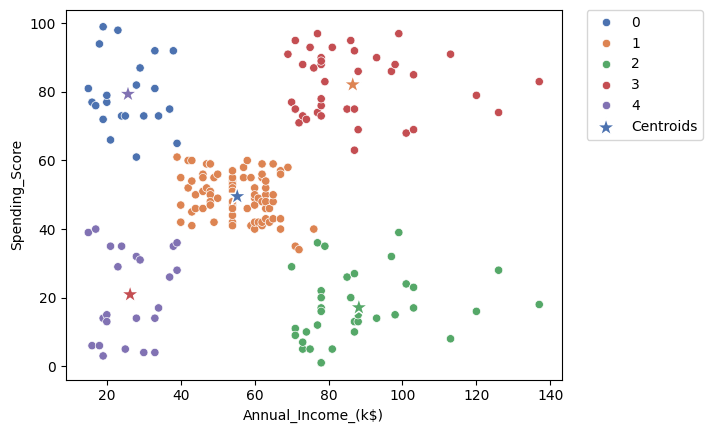

In [ ]:
# Simple way to plot the clusters with their centroids using seaborn and matplotlib.
sns.scatterplot(
    data=df,
    x="Annual_Income_(k$)",
    y="Spending_Score",
    hue="cluster",
    palette="deep"
    )

sns.scatterplot(
    x=fitted_kmeans.cluster_centers_[:, 0],  # x coordinate of the centroids
    y=fitted_kmeans.cluster_centers_[:, 1],  # y coordinate of the centroids
    s=200,
    c=sns.color_palette("deep", 5),
    label='Centroids',
    marker='*')

# Put the legend outside of the figure
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0);

In [226]:
# plot the five clusters in 3D space in each cluster, sorted by number of observations
df['cluster'].value_counts()
three_dim_clusters_fig = px.scatter_3d(
    df,
    x="Annual_Income_(k$)",
    y="Spending_Score",
    z="Age",
    color="cluster",
    height=600, width=600,
    color_discrete_map={0: "blue", 1:"purple", 2:"green", 3:"yellow", 4:"red"},
).update_layout(margin=dict(t=40, l=40, r=40, b=40))

three_dim_clusters_fig.update_traces(marker_size = 3)

three_dim_clusters_fig.show()

# save to file, use everywhere with a browser
#three_dim_clusters_fig.write_html("three_dim_customers.html")

## 5. Model evaluation metrics for clustering (choosing `k`)

In this section we use two metrics — the **elbow method (WCSS)** and the **silhouette score** — to get a suggestion for a good number of clusters `k`. This should be done first, but for presentation and teaching purposes we showed how KMeans is applied in scikit-learn first.

We will now use all four features (`Genre`, `Age`, `Annual_Income_(k$)`, `Spending_Score`) instead of just two. Because `Genre` is categorical, we first encode it as a numeric "dummy" column.

In [227]:
df.columns

Index(['Genre', 'Age', 'Annual_Income_(k$)', 'Spending_Score', 'cluster'], dtype='object')

In [228]:
# Create the matrix X of the features to use in the algorithm
X = df[["Genre", "Age", "Annual_Income_(k$)", "Spending_Score"]]

# show first rows
X.head(2)

,Genre,Age,Annual_Income_(k$),Spending_Score
0,Male,19,15,39
1,Male,21,15,81


### 5.1. Encoding the categorical feature (`Genre` → `Gender`)

**What values does `KMeans` actually need?**

`KMeans` uses **Euclidean distance** to assign points to centroids, so every feature must be **numeric**. It does not care about *types* — only that arithmetic works.

- `pd.get_dummies(..., drop_first=True)` returns **`True`/`False`** values (a boolean Series).
- Booleans behave as `1` (True) and `0` (False) in numeric operations, so KMeans runs without complaint and gives identical results to the integer-encoded version.
- It is still cleaner to **cast explicitly to `int`** so the column reads as `0/1`. This avoids surprises if the column is later combined with other numeric features, scaled, or exported.

Below we encode `Genre` so that **`Male = 1`, `Female = 0`** (`drop_first=True` drops the alphabetically first category, `Female`).

In [229]:
# encode the categorical Genre column as 0/1 for use in KMeans
# pd.get_dummies with drop_first=True drops "Female" alphabetically and keeps "Male"
# .astype(int) converts the True/False output to clean 0/1 integers (Male=1, Female=0)
X["Gender"] = pd.get_dummies(X.Genre, drop_first=True, prefix="Genre").astype(int)
X.head(3)

,Genre,Age,Annual_Income_(k$),Spending_Score,Gender
0,Male,19,15,39,1
1,Male,21,15,81,1
2,Female,20,16,6,0


In [230]:
# drop the Genre column from X. We now use the Gender column.
X = X.drop("Genre", axis=1)
# show first 3 rows
X.head(3)

,Age,Annual_Income_(k$),Spending_Score,Gender
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0


### 5.2. Elbow method (WCSS)

**What is WCSS?** WCSS stands for *Within-Cluster Sum of Squares*. For each cluster, we take every point that belongs to it, measure the squared distance from that point to the cluster's centroid (centre), and add all of those squared distances together. WCSS is the sum across **all** clusters.

A **lower WCSS** means points sit closer to their centroid, i.e. tighter clusters. WCSS always decreases as we add more clusters (with `k = n` clusters, every point would be its own centroid and WCSS would be 0), so we cannot simply minimise it. Instead, we look for the **"elbow"** in the curve: the value of `k` after which adding another cluster no longer produces a meaningful drop in WCSS.

In scikit-learn, WCSS is exposed as the `inertia_` attribute of a fitted `KMeans` model.

Apply KMeans with four features and 1 to 15 clusters to demonstrate the elbow method.   
Look at the "elbow" — the point at which you get not much more valuable info by having more clusters.

In [231]:
# empty list to contain the score of each cluster.
clustering_score = []

# Loop 15 times.
# Create and fit 15 models.
# Get the inertia score for 15 models, from 1 cluster to 15.
for clusters_number in range(1, 15):
    # initiate and customize algo
    model = KMeans(n_clusters=clusters_number, random_state=0)
    # fit algo to the data
    model.fit(X)
    # inertia_ = Sum of squared distances of samples to their closest cluster center.
    # this is the Within Clusters Sum of Squares metric, WCSS
    clustering_score.append(model.inertia_)

In [232]:
# show the list with the clusters' score from 1 to 10
clustering_score

[308862.06,
 212889.44245524294,
 143391.5923603568,
 105299.98742210325,
 82657.05476706794,
 58387.211042939205,
 52544.81463287703,
 44389.80767355768,
 40670.98996236322,
 37201.527044768765,
 35360.07987012988,
 33108.3862914863,
 31667.76129148629,
 30472.52296176046]

In [233]:
# WCSS score for 1 cluster
clustering_score[0]  # first item in the list

308862.06

In [234]:
# WCSS score for 2 clusters
clustering_score[1]  # second item in the list

212889.44245524294

In [235]:
# creata pandas dataframe from list of clustering WCSS score
wcss_df = pd.DataFrame({'clusters_score':clustering_score})

In [236]:
# creata new column of dataframe from range of clusters
wcss_df["clusters_number"] = pd.Series(range(1,11))

In [237]:
#show clusters score for number of clusters
wcss_df

,clusters_score,clusters_number
0,308862.060000,1.0
1,212889.442455,2.0
2,143391.592360,3.0
3,105299.987422,4.0
4,82657.054767,5.0
5,58387.211043,6.0
6,52544.814633,7.0
7,44389.807674,8.0
8,40670.989962,9.0
9,37201.527045,10.0


We see that from 4 to five clusters there is a large reduction in WCSS, but from 5 to 6 there is a reduction from 58348 to 51132, much smaller.   
The reduction in WCSS from 6 to 7 clusters is similar.  

There is a much smaller reduction from 7 to 8 clusters.

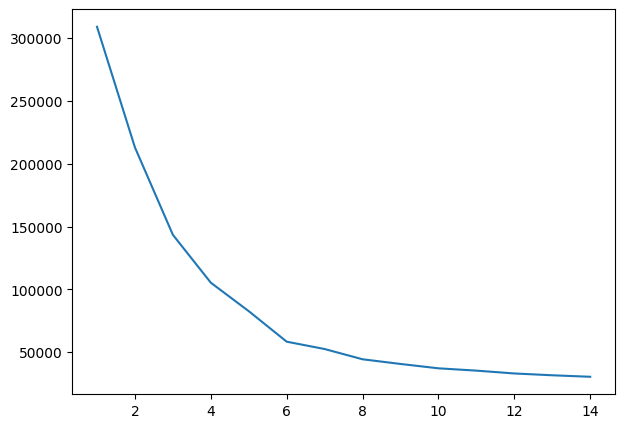

In [238]:
plt.figure(figsize=(7,5))

#plot the simple range from 1 to 10 on x and the clustering score on y.
plt.plot(range(1, 15), clustering_score);

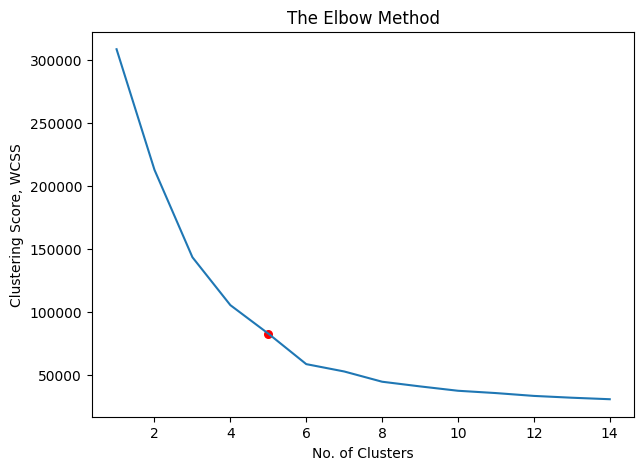

In [239]:
# plot WCSS
# create a figure and set size
plt.figure(figsize=(7,5))

#plot the simple range from 1 to 10 on x and the clustering score on y.
plt.plot(range(1, 15), clustering_score)

#plot a red o on number 5 on x axis, and the WCSS score 
plt.scatter(5, clustering_score[4], s = 30, c = 'red', marker='o')

# add title and labels
plt.title('The Elbow Method')
plt.xlabel('No. of Clusters')
plt.ylabel('Clustering Score, WCSS');

We also see that the slope of the curve from 5 to 6 clusters is reduced but very slightly. This suggests five clusters are a good choice.
But using four features instead of two suggest that 6 cluster might also be a good choice.

### 5.3. Silhouette score

**What is the silhouette score?**   
It measures how well each point fits inside its own cluster compared to the next-nearest cluster. For every point we compute two numbers:

- `a` = the mean distance from the point to all **other points in its own cluster** (how *cohesive* the cluster is).
- `b` = the mean distance from the point to all points in the **nearest neighbouring cluster** (how *separated* the clusters are).

The point's silhouette is then `(b - a) / max(a, b)`, a value between **-1 and +1**. Close to **+1** means the point is well inside its cluster; around **0** means it sits on the border between two clusters; **negative** suggests it may have been assigned to the wrong cluster. The overall silhouette score reported below is the **average** of these per-point values.

Unlike WCSS, **higher silhouette is better**, so we can pick the `k` that maximises it directly.

scikit-learn silhouette score [function and examples.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)

For a more advanced reading on silhouette score you may read this [tutorial.](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py)   

For more advanced clustering performance evaluation methods, you may read this [guide.](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation)

In [240]:
# Create empty list to store score
silhouette_scores_list = []

# loop from 2 to 15 clusters:
for clusters_number in range(2, 15):  # Silhouette starts from 2 clusters.
    # initiate and customize algo
    model = KMeans(n_clusters=clusters_number, random_state=0)
    # fit algo to the data
    clusters = model.fit_predict(X)
    # calculate silhouette score for each number of clusters
    silhouette_metric_score = silhouette_score(X, clusters)
    # append each score to the list
    silhouette_scores_list.append(silhouette_metric_score)
    print(
        f"For clusters={clusters_number}, the average silhouette_score is: {silhouette_metric_score}")

For clusters=2, the average silhouette_score is: 0.29307334005502633
For clusters=3, the average silhouette_score is: 0.383798873822341
For clusters=4, the average silhouette_score is: 0.3921703094115865
For clusters=5, the average silhouette_score is: 0.37688936241822546
For clusters=6, the average silhouette_score is: 0.4506609653808789
For clusters=7, the average silhouette_score is: 0.44296270060494874
For clusters=8, the average silhouette_score is: 0.425945425758392
For clusters=9, the average silhouette_score is: 0.4116310808490313
For clusters=10, the average silhouette_score is: 0.381660187556178
For clusters=11, the average silhouette_score is: 0.36033505379654224
For clusters=12, the average silhouette_score is: 0.34759845392414923
For clusters=13, the average silhouette_score is: 0.3441300920503319
For clusters=14, the average silhouette_score is: 0.339298825170399


In [241]:
# The percentage difference for silhouette score for 6 versus five clusters
((0.45-0.376)/0.376) * 100

19.68085106382979

We get a higher silhouette score for 6 clusters.   
Around 20% higher versus 5 clusters.


### 5.4. Further reading on clustering evaluation metrics

- [Scikit-learn model evaluation and metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#metrics-and-scoring-quantifying-the-quality-of-predictions)   
- [Clustering performance evaluation](https://scikit-learn.org/stable/modules/clustering.html#clustering-evaluation)   

If there are no labels, use:   

- [Silhouette Coefficient](https://scikit-learn.org/stable/modules/clustering.html#silhouette-coefficient)  
- [Calinski-Harabasz index](https://scikit-learn.org/stable/modules/clustering.html#calinski-harabasz-index)

## 6. Apply KMeans with four features and six clusters

In [242]:
# our data until now, grouped in 5 clusters
df.head(3)

,Genre,Age,Annual_Income_(k$),Spending_Score,cluster
0,Male,19,15,39,4
1,Male,21,15,81,0
2,Female,20,16,6,4


In [243]:
#show the features matrix
X.head(3)
# remember we have encoded "Genre" as "Gender".

,Age,Annual_Income_(k$),Spending_Score,Gender
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0


In [244]:
# Create KMeans model with 6 clusters.
model = KMeans(n_clusters=6, random_state=0)
# fit algo to the data
six_clusters_fit = model.fit(X)
six_clusters_kmeans = model.fit_predict(X)

In [245]:
# Show the clusters in which each observation has been assigned to
six_clusters_kmeans

array([2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5,
       2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 0, 5, 2, 5,
       2, 5, 0, 4, 4, 4, 0, 4, 4, 0, 0, 0, 0, 0, 4, 0, 0, 4, 0, 0, 0, 4,
       0, 0, 4, 4, 0, 0, 0, 0, 0, 4, 0, 4, 4, 0, 0, 4, 0, 0, 4, 0, 0, 4,
       4, 0, 0, 4, 0, 4, 4, 4, 0, 4, 0, 4, 4, 0, 0, 4, 0, 4, 0, 0, 0, 0,
       0, 4, 4, 4, 4, 4, 0, 0, 0, 0, 4, 4, 4, 1, 4, 1, 4, 1, 3, 1, 3, 1,
       4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [246]:
# create a new column, add it to the dataframe to show cluster sof observations.
df["six_clusters"] = pd.DataFrame(
    six_clusters_kmeans, columns=["six_clusters"])

# set six clusters column values as category data type
df["six_clusters"] = df["six_clusters"].astype('category')

In [247]:
# show first 4 rows
df.head(4)

,Genre,Age,Annual_Income_(k$),Spending_Score,cluster,six_clusters
0,Male,19,15,39,4,2
1,Male,21,15,81,0,5
2,Female,20,16,6,4,2
3,Female,23,16,77,0,5


In [248]:
# plot the six clusters in the 3D space
three_dim_six_clusters = px.scatter_3d(
    df, 
    x="Annual_Income_(k$)", 
    y="Spending_Score",
    z="Age",
    color="six_clusters",
    height=700, width=1000,
    color_discrete_map={0: "blue", 1:"purple", 2:"green", 3:"yellow", 4:"red", 5:"brown"},
    size='Annual_Income_(k$)',
).update_layout(margin=dict(t=50, l=60, r=60, b=40))

# three_dim_six_clusters.update_traces(marker_size=3)  # uncomment to make the points smaller
three_dim_six_clusters.show()

# save to file, use everywhere with a browser
#three_dim_clusters.write_html("three_dim_customers.html")  

Examining the data, we see that the customers with spending score 40 to 60 have been devided to two clusters, based on their age.    
The new cluster mainly contains customers above 40+ with high spending score. It is designated as cluster 1 in this case, and this the larger cluster.  

**Important reminder: After all, the number of clusters is also a matter of policy decisions.**

## 7. Define, describe and label clusters after examining them one by one.

In [249]:
# plot one of the six clusters, cluster "zero" in the 3D space to examine it
plot_cluster_zero = px.scatter_3d(
    df[df["six_clusters"] == 0],  # Just change the dataframe to filter out all other clusters
    x="Annual_Income_(k$)",
    y="Spending_Score",
    z="Age",
    color="six_clusters", height=800, width=800,
    color_discrete_map={
        0: "blue", 1:"purple", 2:"green", 3:"black", 4:"red", 5:"brown"},
    # size='Annual_Income_(k$)'  # Not needed because I don't compare it with aothe clusters.
).update_layout(margin=dict(t=50, l=60, r=60, b=40))

plot_cluster_zero.update_traces(marker_size=4)

plot_cluster_zero.show()

In [250]:
# show basic descriptive stats for cluster labeled as 0.
df[df["six_clusters"] == 0].describe()

,Age,Annual_Income_(k$),Spending_Score
count,44.000000,44.000000,44.000000
mean,56.340909,53.704545,49.386364
std,8.550651,8.239382,5.993081
min,43.000000,38.000000,35.000000
25%,49.000000,47.000000,45.750000
50%,54.000000,54.000000,49.000000
75%,65.250000,62.000000,55.000000
max,70.000000,67.000000,60.000000


**How would you describe, define this "cluster 0" in a few words? How would you "label" it in one or two words to remember it?**     
How is this cluster different from others?    
I define it as: "45ers and above, with average income and average spending relative to their income".  
And label them as: "wise_constrained", implyting that they are wise because they spend according to their budget constraint, and are also wise "age-wise".

In [251]:
# plot out of the six clusters, cluster "one" in the 3D space to examine it
plot_cluster_one = px.scatter_3d(
    df[df["six_clusters"] == 1],  # Just change the dataframe to filter out all other clusters
    x="Annual_Income_(k$)",
    y="Spending_Score",
    z="Age",
    color="six_clusters",
    height=800, width=800,
    color_discrete_map={
        0: "blue", 1:"purple", 2:"green", 3:"black", 4:"red", 5:"brown"},
    # size='Annual_Income_(k$)'  # Not needed because I don't compare it with another cluster.
).update_layout(margin=dict(t=50, l=60, r=60, b=40))

plot_cluster_one.update_traces(marker_size=4)

plot_cluster_one.show()

In [252]:
# statistically describe the observations that belong to cluster 1.
df[df["six_clusters"] == 1].describe()

,Age,Annual_Income_(k$),Spending_Score
count,39.000000,39.000000,39.000000
mean,32.692308,86.538462,82.128205
std,3.728650,16.312485,9.364489
min,27.000000,69.000000,63.000000
25%,30.000000,75.500000,74.500000
50%,32.000000,79.000000,83.000000
75%,35.500000,95.000000,90.000000
max,40.000000,137.000000,97.000000


**How would you describe, define this "cluster one" in a few words? How would you "label" it in one or two words to remember it?**     
How is this cluster different from others?    
Let's see... hmmm ... Age 27 to 40, high to very high income, very high spending score.   
I assume that perhaps they are postgraduates from BIS UoA that after ther masters started finally earning a nice salary and now they want to enjoy it.  

I define this cluster as: "in their thirties, with a lot of cash and finally can spend a lot".  
And label them as: "start_earning_living_it", implyting that they enjoy spending now that they started earning it after working and studying hard for years.

In [ ]:
# plot "cluster two" out of the six clusters in the 3D space to examine it
plot_cluster_two = px.scatter_3d(
    df[df["six_clusters"] == 2],  # Just change the dataframe to filter out all other clusters
    x="Annual_Income_(k$)",
    y="Spending_Score",
    z="Age",
    color="six_clusters",
    height=800, width=800,
    color_discrete_map={
        0: "blue", 1:"purple", 2:"green", 3:"black", 4:"red", 5:"brown"},
    # size='Annual_Income_(k$)'  # Not needed because I don't compare it with another cluster.
).update_layout(margin=dict(t=50, l=60, r=60, b=40))

plot_cluster_two.show()

In [254]:
# statistically describe the observations that belong to cluster 2.
df[df["six_clusters"] == 2].describe()

,Age,Annual_Income_(k$),Spending_Score
count,22.000000,22.000000,22.000000
mean,44.318182,25.772727,20.272727
std,12.800247,7.646548,12.947446
min,19.000000,15.000000,3.000000
25%,35.250000,19.250000,7.750000
50%,45.500000,24.500000,16.000000
75%,52.750000,32.250000,31.750000
max,67.000000,39.000000,40.000000


**How would you describe, define this "cluster two" in a few words? How would you "label" it in one or two words to remember it?**     
How is this cluster different from others?    
Let's see... hmmm ... all ages, very low income, very low spending score.   
 
I would label them as: "have_not_spend_not", implying that they don't spend a lot because they don't have a lot.

In [255]:
# statistically describe the observations that belong to cluster 3.
df[df["six_clusters"] == 3].describe()

,Age,Annual_Income_(k$),Spending_Score
count,34.000000,34.000000,34.000000
mean,41.647059,88.735294,16.764706
std,11.058748,16.332360,9.881292
min,19.000000,71.000000,1.000000
25%,34.500000,78.000000,10.000000
50%,42.500000,85.500000,15.500000
75%,47.750000,97.750000,22.750000
max,59.000000,137.000000,39.000000


**How would you describe, define this "cluster three" in a few words? How would you "label" it in one or two words to remember it?**     
How is this cluster different from others?    
Let's see... hmmm ... all ages, high to very income, low to very low spending score.   
 
I would label them as: "savers_or_spend_elsewhere", implying that they don't spend a lot because they save it, or they don't spend it at the Mall.

In [256]:
# statistically describe the observations that belong to cluster 4.
df[df["six_clusters"] == 4].describe()

,Age,Annual_Income_(k$),Spending_Score
count,38.000000,38.000000,38.000000
mean,27.315789,57.500000,48.447368
std,7.472853,9.722501,7.924295
min,18.000000,40.000000,29.000000
25%,21.000000,49.500000,42.000000
50%,26.500000,60.000000,49.500000
75%,32.000000,64.000000,55.000000
max,43.000000,76.000000,60.000000


**How would you describe, define this "cluster four" in a few words? How would you "label" it in one or two words to remember it?**     
How is this cluster different from others?     
I would label them as: "young_cautious", implying that they don't spend a lot because of they are budget constrained, and tehy are young.  
This cluster differs to cluster zero mostly because of their age.

In [257]:
# statistically describe the observations that belong to cluster 5.
# Last of six clusters, index in python starts from zero.
df[df["six_clusters"] == 5].describe()

,Age,Annual_Income_(k$),Spending_Score
count,23.000000,23.000000,23.000000
mean,25.521739,26.304348,78.565217
std,5.273170,7.893811,10.953729
min,18.000000,15.000000,61.000000
25%,21.500000,19.500000,73.000000
50%,24.000000,25.000000,77.000000
75%,30.000000,33.000000,84.500000
max,35.000000,39.000000,99.000000


**How would you describe, define this "cluster five" in a few words? How would you "label" it in one or two words to remember it?**     
How is this cluster different from others?     
Yound age, max age is 35, low income, high to super high spending score
I would label them as: "young_yolos", implying that they don't spend it all now that they are young, despite not having a lot. 

In [258]:
# Replace the cluster number with my labels to help me remember what the cluster groups might suggest.
my_funny_intuitite_cluster_labes = {0: "wise_constrained",
                                    1: "start_earning_living_it",
                                    2: "have_not_spend_not",
                                    3: "save_or_spend_elsewhere",
                                    4: "young_cautious",
                                    5: "young_yolos",
}

In [259]:
# Create new column assigning my labels according to cluster number.
df["six_clusters_labels"] = df["six_clusters"].map(my_funny_intuitite_cluster_labes)

In [260]:
# show first rows of data
df.head(4)

,Genre,Age,Annual_Income_(k$),Spending_Score,cluster,six_clusters,six_clusters_labels
0,Male,19,15,39,4,2,have_not_spend_not
1,Male,21,15,81,0,5,young_yolos
2,Female,20,16,6,4,2,have_not_spend_not
3,Female,23,16,77,0,5,young_yolos


**Notice the new cluster in the middle. It is only a matter of age.** 

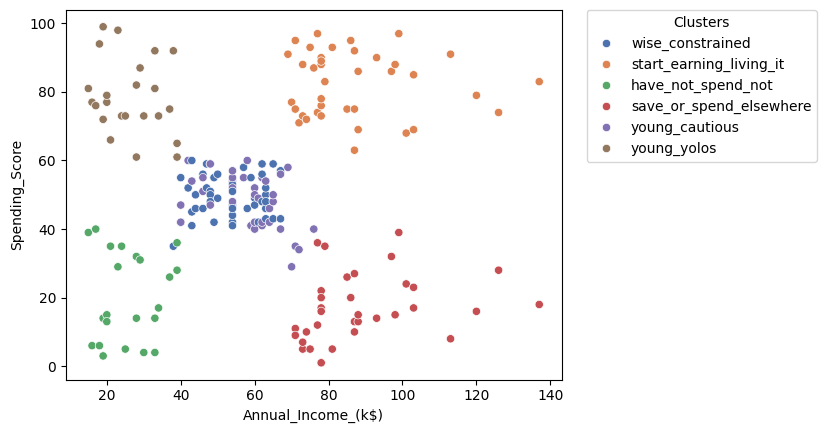

In [261]:
# 2D plot the six clusters, use as legend the new labels.

sns.scatterplot(
    x="Annual_Income_(k$)",
    y="Spending_Score",
    hue="six_clusters_labels",
    data=df, palette="deep")

# also add cluster numbers next to text in the legend
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0, title="Clusters");   


In [262]:
# 3D plot the six clusters with descriptive legend labels.
cluster_legend_labels = {
    "wise_constrained": "wise_constrained: 40+, average income, moderate spending",
    "start_earning_living_it": "start_earning_living_it: age 27-40, high income, very high spending",
    "have_not_spend_not": "have_not_spend_not: low income, low spending",
    "save_or_spend_elsewhere": "save_or_spend_elsewhere: high income, low spending",
    "young_cautious": "young_cautious: under 35, low income, low spending",
    "young_yolos": "young_yolos: under 35, low income, very high spending",
}

# Plot using long labels in legend so each cluster description is visible.
three_dim_six_clusters_labels = px.scatter_3d(
    df.assign(
        six_clusters_labels_long=df["six_clusters_labels"].map(cluster_legend_labels)
    ),
    x="Annual_Income_(k$)",
    y="Spending_Score",
    z="Age",
    color="six_clusters_labels_long",
    height=800,
    width=1400,
    color_discrete_map={
        cluster_legend_labels["wise_constrained"]: "blue",
        cluster_legend_labels["start_earning_living_it"]: "purple",
        cluster_legend_labels["have_not_spend_not"]: "green",
        cluster_legend_labels["save_or_spend_elsewhere"]: "yellow",
        cluster_legend_labels["young_cautious"]: "red",
        cluster_legend_labels["young_yolos"]: "brown",
    },
    size="Annual_Income_(k$)",
).update_layout(
    margin=dict(t=50, l=60, r=420, b=40),
    legend=dict(
        title="Cluster label and profile",
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.9)",
        bordercolor="lightgray",
        borderwidth=1,
    ),
)

three_dim_six_clusters_labels.update_traces(marker_size=4)

three_dim_six_clusters_labels.show()

In [ ]:
# 3D plot three out of the six clusters to compare them.
three_dim_six_clusters_labels = px.scatter_3d(
    df[(df["six_clusters_labels"] == "wise_constrained") |
       (df["six_clusters_labels"] == "start_earning_living_it") |
       (df["six_clusters_labels"] == "have_not_spend_not")],
    x="Annual_Income_(k$)",
    y="Spending_Score",
    z="Age",
    color="six_clusters_labels", 
    height=800, width=800,
    color_discrete_map={
        "wise_constrained": "blue",
        "start_earning_living_it":"purple",
        "have_not_spend_not":"green"},
    size='Annual_Income_(k$)',
).update_layout(margin=dict(t=50, l=60, r=60, b=40))

three_dim_six_clusters_labels.show()

In [264]:
# Show clusters by size
df.groupby('six_clusters', observed=False).size()

six_clusters
0    44
1    39
2    22
3    34
4    38
5    23
dtype: int64

In [265]:
# group cluster labeled as 1, by gender and show size
df[df["six_clusters"] == 1].groupby("Genre").size()

Genre
Female    21
Male      18
dtype: int64

## 8. Extra reading about clustering and unsupervised learning.

[Unsupervised learning algorithms in scikit learn.](https://scikit-learn.org/stable/unsupervised_learning.html)    
Clustering is a small subset of unsupervised learning.     
[Clustering algorithms in scikit learn.](https://scikit-learn.org/stable/modules/clustering.html#)